In [42]:
##### Calculate and map spatial autocorrelation in model residual
# Can only run if using non-thinned sample because otherwise there are no neighbors by construction
# Takes outputs from model run run (predictions.parquet + config.json) as input

# Weights matrix strategy:
# Primary: Queen contiguity from polygon boundaries (standard choice for areal Moran's I)
# Fallback: k-nearest-neighbors (from point coordinates) used to connect any regions left as "islands" (zero neighbors) after contiguity 

import os
from pathlib import Path
import json
import pandas as pd
import geopandas as gpd
import numpy as np
from libpysal.weights import Queen, KNN, W
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot, lisa_cluster
import matplotlib.pyplot as plt

In [43]:
### SET-UP 

cd = os.path.dirname(os.getcwd())

model_run = 'labor_tonne_rtv_rf_sqrt_inverse'
target_column = 'rtv_log_labor_intensity_jobs_per_million_tonne'

# import model results 
results = pd.read_parquet(f"{cd}/Results/RF_models/{model_run}/predictions.parquet")

# import boundaries 
boundaries  = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_total.shp")   
lat_lon = pd.read_csv(f"{cd}/Data/Clean/Predictors/Vectors/lat_lon.csv")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/morans_I"

In [44]:
##### Prep predictions data 

# Average predictions across folds for each subnational region 
results_avg = results.groupby('PROJ_ID')[[target_column, 'prediction']].mean().reset_index()

# Compute residuals (log scale)
results_avg['residual'] = results_avg[target_column] - results_avg['prediction']

# Add to boundaries
results_avg_geo = boundaries.merge(results_avg, on='PROJ_ID', how='left')
results_avg_geo = results_avg_geo.dropna(subset=['residual']).reset_index(drop=True)


('WARNING: ', 7, ' is an island (no neighbors)')
('WARNING: ', 10, ' is an island (no neighbors)')
('WARNING: ', 11, ' is an island (no neighbors)')
('WARNING: ', 17, ' is an island (no neighbors)')
('WARNING: ', 23, ' is an island (no neighbors)')
('WARNING: ', 49, ' is an island (no neighbors)')
('WARNING: ', 65, ' is an island (no neighbors)')
('WARNING: ', 81, ' is an island (no neighbors)')
('WARNING: ', 95, ' is an island (no neighbors)')
('WARNING: ', 214, ' is an island (no neighbors)')
('WARNING: ', 287, ' is an island (no neighbors)')
('WARNING: ', 289, ' is an island (no neighbors)')
('WARNING: ', 306, ' is an island (no neighbors)')
('WARNING: ', 307, ' is an island (no neighbors)')
('WARNING: ', 310, ' is an island (no neighbors)')
('WARNING: ', 312, ' is an island (no neighbors)')
('WARNING: ', 313, ' is an island (no neighbors)')
('WARNING: ', 314, ' is an island (no neighbors)')
('WARNING: ', 315, ' is an island (no neighbors)')
('WARNING: ', 319, ' is an island (no nei

/Users/carinamanitius/Library/Python/3.9/lib/python/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 1046 disconnected components.
 There are 883 islands with ids: 7, 10, 11, 17, 23, 49, 65, 81, 95, 214, 287, 289, 306, 307, 310, 312, 313, 314, 315, 319, 320, 321, 334, 340, 367, 410, 488, 492, 508, 526, 527, 535, 548, 557, 565, 575, 576, 582, 588, 603, 606, 607, 611, 612, 617, 618, 626, 630, 632, 638, 640, 643, 646, 647, 648, 654, 656, 662, 664, 669, 671, 672, 675, 683, 684, 687, 688, 690, 691, 694, 699, 701, 703, 706, 708, 709, 710, 711, 712, 713, 715, 716, 718, 719, 720, 721, 723, 724, 725, 726, 727, 729, 730, 731, 735, 736, 737, 738, 739, 740, 741, 742, 743, 744, 747, 748, 750, 751, 752, 753, 754, 755, 756, 757, 759, 760, 761, 762, 763, 764, 765, 766, 767, 768, 769, 770, 771, 772, 776, 778, 779, 782, 784, 787, 788, 789, 790, 791, 792, 793, 794, 795, 796, 797, 798, 799, 800, 801, 802, 803, 804, 805, 806, 807, 810, 811, 

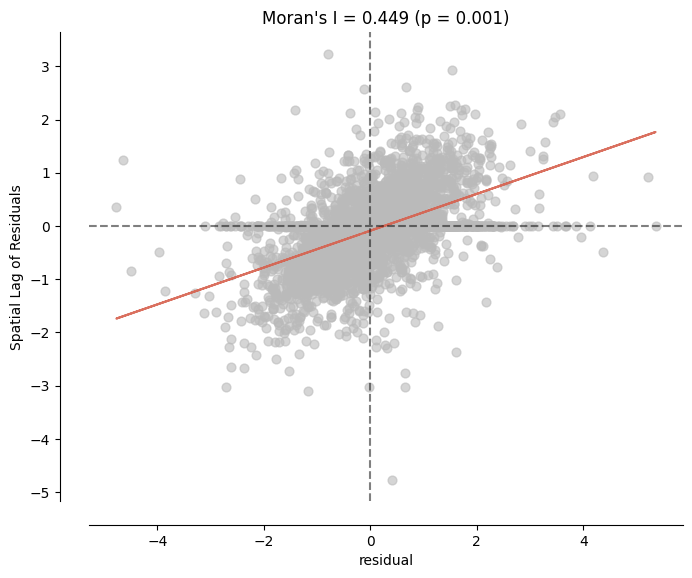

/Users/carinamanitius/Library/Python/3.9/lib/python/site-packages/esda/moran.py:1059: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


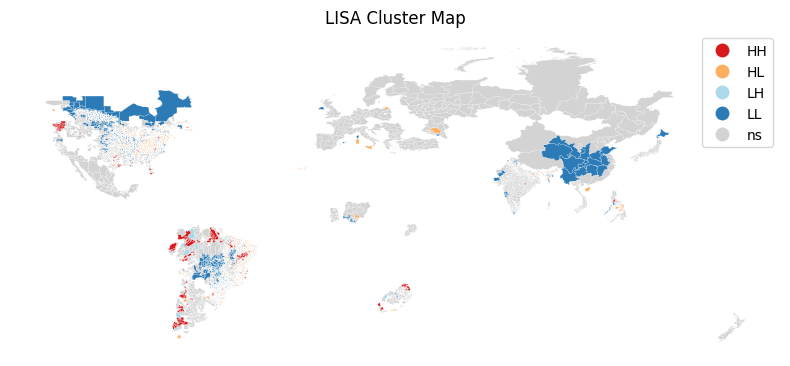

In [45]:
##### Plot Moran's I

# Build spatial weights
# Queen contiguity is for polygons sharing edges/vertices
w = Queen.from_dataframe(results_avg_geo, use_index=False)
w.transform = "r"  # row-standardize weights

# Compute Moran's I
y = results_avg_geo['residual'].values
moran = Moran(y, w)

print(f"Moran's I: {moran.I:.4f}")
print(f"Expected I under null: {moran.EI:.4f}")
print(f"p-value (simulated): {moran.p_sim:.4f}")
print(f"z-score: {moran.z_sim:.4f}")

# Plot Moran scatterplot
fig, ax = moran_scatterplot(moran, aspect_equal=True)
ax.set_xlabel('residual')
ax.set_ylabel(f"Spatial Lag of Residuals")
ax.set_title(f"Moran's I = {moran.I:.3f} (p = {moran.p_sim:.3f})")
plt.tight_layout()
plt.show()
fig.savefig(f"{fd}/{model_run}residual_scatterplot.png", dpi=300, bbox_inches='tight')

# Plot LISA cluster map
# Calculate Local Moran's I
moran_local = Moran_Local(y, w)

# Plot LISA clusters
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
lisa_cluster(moran_local, results_avg_geo, p=0.05, ax=ax)
ax.set_title("LISA Cluster Map")
ax.axis("off")
plt.tight_layout()
plt.show()
fig.savefig(f"{fd}/{model_run}_residual_LISA.png", dpi=300, bbox_inches='tight')